# Data Understanding

### Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import sys

Mounted at /content/drive


In [5]:
dt = pd.read_csv('/content/drive/My Drive/dataset/DataCoSupplyChainDataset.csv', encoding='latin1')

### Menelaah Data

In [6]:
print("Informasi Dataset:")
dt.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fn

In [7]:
print("Statistik deskriptif:")
dt.describe()

Statistik deskriptif:


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [8]:
print("Jumlah missing value:")
dt.isnull().sum()

Jumlah missing value:


,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [9]:
print("Jumlah data duplikat:")
print(dt.duplicated().sum())

Jumlah data duplikat:
0


Cek distribusi target

In [10]:
target = 'Late_delivery_risk'

print("Distribusi target:")
print(dt[target].value_counts())

print("\nDistribusi target dalam persen:")
print(dt[target].value_counts(normalize=True) * 100)

Distribusi target:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Distribusi target dalam persen:
Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


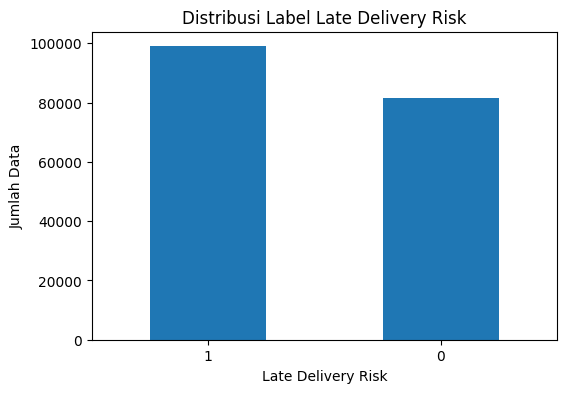

In [11]:
plt.figure(figsize=(6, 4))
dt[target].value_counts().plot(kind='bar')
plt.title('Distribusi Label Late Delivery Risk')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

Pilih fitur untuk model high accuracy

In [12]:
fitur = [
    'Type',
    'Days for shipping (real)',
    'Benefit per order',
    'Sales per customer',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Market',
    'Order City',
    'Order Country',
    'Order Region',
    'Order State',
    'Order Status',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Name',
    'Product Price',
    'Shipping Mode'
]

target = 'Late_delivery_risk'

dt_model = dt[fitur + [target]].copy()

print("Data model berhasil dibuat")
print(dt_model.shape)

dt_model.head()

Data model berhasil dibuat
(180519, 25)


,Type,Days for shipping (real),Benefit per order,Sales per customer,Category Name,Customer Segment,Department Name,Market,Order City,Order Country,...,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Name,Product Price,Shipping Mode,Late_delivery_risk
0,DEBIT,3,91.250000,314.640015,Sporting Goods,Consumer,Fitness,Pacific Asia,Bekasi,Indonesia,...,327.75,0.29,1,327.75,314.640015,91.250000,Smart watch,327.75,Standard Class,0
1,TRANSFER,5,-249.089996,311.359985,Sporting Goods,Consumer,Fitness,Pacific Asia,Bikaner,India,...,327.75,-0.80,1,327.75,311.359985,-249.089996,Smart watch,327.75,Standard Class,1
2,CASH,4,-247.779999,309.720001,Sporting Goods,Consumer,Fitness,Pacific Asia,Bikaner,India,...,327.75,-0.80,1,327.75,309.720001,-247.779999,Smart watch,327.75,Standard Class,0
3,DEBIT,3,22.860001,304.809998,Sporting Goods,Home Office,Fitness,Pacific Asia,Townsville,Australia,...,327.75,0.08,1,327.75,304.809998,22.860001,Smart watch,327.75,Standard Class,0
4,PAYMENT,2,134.210007,298.250000,Sporting Goods,Corporate,Fitness,Pacific Asia,Townsville,Australia,...,327.75,0.45,1,327.75,298.250000,134.210007,Smart watch,327.75,Standard Class,0


Cek missing value pada data model

In [13]:
print("Missing value pada data model:")
dt_model.isnull().sum()

Missing value pada data model:


,0
Type,0
Days for shipping (real),0
Benefit per order,0
Sales per customer,0
Category Name,0
Customer Segment,0
Department Name,0
Market,0
Order City,0
Order Country,0


Pisahkan fitur dan target

In [14]:
X = dt_model.drop(columns=[target])
y = dt_model[target].astype(int)

print("Jumlah data fitur X:", X.shape)
print("Jumlah data target y:", y.shape)

Jumlah data fitur X: (180519, 24)
Jumlah data target y: (180519,)


Pisahkan kolom numerik dan kategorikal

In [15]:
kolom_numerik = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Kolom numerik:")
print(kolom_numerik)

print("\nKolom kategorikal:")
print(kolom_kategorikal)

Kolom numerik:
['Days for shipping (real)', 'Benefit per order', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']

Kolom kategorikal:
['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


Split data training dan testing

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (144415, 24)
X_test : (36104, 24)


Buat preprocessing dan model Random Forest

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, kolom_numerik),
        ('cat', categorical_transformer, kolom_kategorikal)
    ]
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

hasil_depth = []

for depth in [1, 2, 3, 4, 5, 6, 7, 8, 10, 12]:
    rf_model = RandomForestClassifier(
        n_estimators=50,
        max_depth=depth,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', rf_model)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)

    hasil_depth.append({
        'max_depth': depth,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    })

hasil_depth_df = pd.DataFrame(hasil_depth)
hasil_depth_df['selisih_dari_90'] = abs(hasil_depth_df['accuracy'] - 0.90)

display(hasil_depth_df.sort_values(by='selisih_dari_90'))

In [ ]:
depth_terpilih = 2

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=depth_terpilih,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

model_pipeline.fit(X_train, y_train)

print("Training model final selesai dengan max_depth =", depth_terpilih)

In [ ]:
y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== HASIL EVALUASI MODEL RANDOM FOREST FINAL ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Tidak Terlambat', 'Berisiko Terlambat']
))

In [ ]:
import joblib

model_path = '/content/drive/My Drive/dataset/rf_late_delivery_final.pkl'
fitur_path = '/content/drive/My Drive/dataset/fitur_final.pkl'
sample_path = '/content/drive/My Drive/dataset/sample_data_dashboard.csv'

joblib.dump(model_pipeline, model_path)
joblib.dump(fitur, fitur_path)

X_test.head(100).to_csv(sample_path, index=False)

print("Model final berhasil disimpan di:", model_path)
print("Daftar fitur berhasil disimpan di:", fitur_path)
print("Sample data dashboard berhasil disimpan di:", sample_path)

In [ ]:
!pip install streamlit pyngrok -q

In [ ]:
!ngrok config add-authtoken "3EZPkd2LlesaodpmH3tsmoPmyZN_3FXtqBZFN3YmU3UAKA3LP"

In [ ]:
from pyngrok import ngrok
import os, signal, subprocess, time

# Tutup semua tunnel pyngrok
ngrok.kill()

# Matikan proses ngrok yang masih nyangkut
!pkill -f ngrok

print("Tunnel ngrok lama sudah dimatikan.")

In [ ]:
!pkill -f streamlit


In [ ]:
!pkill -f streamlit
!nohup streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &

In [ ]:
!tail -n 20 streamlit.log

In [ ]:
!curl -I http://localhost:8501

In [ ]:
from pyngrok import ngrok

ngrok.kill()

ngrok.set_auth_token("3EZPkd2LlesaodpmH3tsmoPmyZN_3FXtqBZFN3YmU3UAKA3LP")

public_url = ngrok.connect(8501, "http")

print("Klik link dashboard ini:")
print(public_url.public_url)

In [ ]:
%%writefile app.py
import os
import joblib
import pandas as pd
import streamlit as st

# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="ERP SCM | Late Delivery Prediction",
    page_icon="🚚",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================================================
# PATH CONFIGURATION
# =========================================================
BASE_PATH = "/content/drive/My Drive/dataset"

DATA_PATH = os.path.join(BASE_PATH, "DataCoSupplyChainDataset.csv")
MODEL_PATH = os.path.join(BASE_PATH, "rf_late_delivery_final.pkl")
FITUR_PATH = os.path.join(BASE_PATH, "fitur_final.pkl")
SAMPLE_PATH = os.path.join(BASE_PATH, "sample_data_dashboard.csv")

# =========================================================
# MODEL METRICS
# =========================================================
MODEL_ACCURACY = "91.88%"
MODEL_PRECISION = "89.17%"
MODEL_RECALL = "96.96%"
MODEL_F1 = "92.90%"

CONFUSION_MATRIX = pd.DataFrame(
    [[13977, 2331], [602, 19194]],
    columns=["Prediksi Tidak Terlambat", "Prediksi Berisiko Terlambat"],
    index=["Aktual Tidak Terlambat", "Aktual Berisiko Terlambat"]
)

# Fitur yang ditampilkan pada dashboard
DASHBOARD_FEATURES = [
    "Type",
    "Days for shipping (real)",
    "Customer Segment",
    "Market",
    "Order Region",
    "Order Status",
    "Order Item Quantity",
    "Shipping Mode"
]

FEATURE_LABELS = {
    "Type": "Jenis Transaksi",
    "Days for shipping (real)": "Jumlah Hari Pengiriman Aktual",
    "Customer Segment": "Segmen Pelanggan",
    "Market": "Market / Wilayah Pasar",
    "Order Region": "Wilayah Pengiriman",
    "Order Status": "Status Pesanan",
    "Order Item Quantity": "Jumlah Item Pesanan",
    "Shipping Mode": "Metode Pengiriman"
}

# =========================================================
# CUSTOM CSS
# =========================================================
st.markdown("""
<style>
    .stApp {
        background: linear-gradient(180deg, #F8FAFC 0%, #EEF2F7 100%);
        color: #0F172A;
    }

    section[data-testid="stSidebar"] {
        background: linear-gradient(180deg, #0F172A 0%, #1E293B 100%);
    }

    section[data-testid="stSidebar"] * {
        color: #E5E7EB !important;
    }

    .block-container {
        padding-top: 1.2rem;
        padding-bottom: 2rem;
        max-width: 1400px;
    }

    .hero-container {
        background: linear-gradient(135deg, #0F172A 0%, #1D4ED8 55%, #38BDF8 100%);
        padding: 30px 34px;
        border-radius: 24px;
        color: white;
        margin-bottom: 24px;
        box-shadow: 0 18px 35px rgba(15, 23, 42, 0.20);
    }

    .hero-badge {
        display: inline-block;
        background: rgba(255,255,255,0.16);
        border: 1px solid rgba(255,255,255,0.28);
        padding: 7px 13px;
        border-radius: 999px;
        font-size: 13px;
        margin-bottom: 14px;
    }

    .hero-title {
        font-size: 36px;
        font-weight: 850;
        margin-bottom: 8px;
        letter-spacing: -0.7px;
    }

    .hero-subtitle {
        font-size: 16px;
        color: #E0F2FE;
        max-width: 950px;
        line-height: 1.6;
    }

    div[data-testid="stRadio"] {
        background: #FFFFFF;
        border: 1px solid #E2E8F0;
        border-radius: 18px;
        padding: 8px 10px;
        margin-bottom: 22px;
        box-shadow: 0 8px 20px rgba(15, 23, 42, 0.06);
    }

    div[data-testid="stRadio"] > label {
        display: none;
    }

    div[data-testid="stRadio"] div[role="radiogroup"] {
        gap: 8px;
    }

    div[data-testid="stRadio"] label {
        background: #F8FAFC;
        border: 1px solid #E2E8F0;
        border-radius: 14px;
        padding: 10px 16px;
        min-width: 150px;
        justify-content: center;
        transition: all 0.2s ease-in-out;
    }

    div[data-testid="stRadio"] label:hover {
        background: #EFF6FF;
        border-color: #3B82F6;
    }

    div[data-testid="stRadio"] label[data-baseweb="radio"] > div:first-child {
        display: none;
    }

    .kpi-card {
        background: #FFFFFF;
        border: 1px solid #E2E8F0;
        border-radius: 18px;
        padding: 20px 20px;
        box-shadow: 0 10px 25px rgba(15, 23, 42, 0.06);
        min-height: 125px;
    }

    .kpi-label {
        font-size: 13px;
        font-weight: 700;
        color: #64748B;
        text-transform: uppercase;
        letter-spacing: 0.4px;
        margin-bottom: 10px;
    }

    .kpi-value {
        font-size: 30px;
        font-weight: 850;
        color: #0F172A;
        margin-bottom: 6px;
    }

    .kpi-desc {
        font-size: 13px;
        color: #64748B;
    }

    .content-card {
        background: #FFFFFF;
        border: 1px solid #E2E8F0;
        border-radius: 20px;
        padding: 24px;
        box-shadow: 0 12px 28px rgba(15, 23, 42, 0.06);
        margin-bottom: 18px;
    }

    .section-title {
        font-size: 25px;
        font-weight: 850;
        color: #0F172A;
        margin-bottom: 10px;
        letter-spacing: -0.3px;
    }

    .section-subtitle {
        font-size: 15px;
        color: #64748B;
        line-height: 1.6;
        margin-bottom: 18px;
    }

    .status-danger {
        background: linear-gradient(135deg, #991B1B 0%, #EF4444 100%);
        color: white;
        border-radius: 20px;
        padding: 28px;
        text-align: center;
        box-shadow: 0 12px 28px rgba(239, 68, 68, 0.22);
        margin-bottom: 18px;
    }

    .status-success {
        background: linear-gradient(135deg, #065F46 0%, #10B981 100%);
        color: white;
        border-radius: 20px;
        padding: 28px;
        text-align: center;
        box-shadow: 0 12px 28px rgba(16, 185, 129, 0.22);
        margin-bottom: 18px;
    }

    .status-title {
        font-size: 26px;
        font-weight: 850;
        margin-bottom: 8px;
    }

    .status-desc {
        font-size: 15px;
        opacity: 0.92;
    }

    .recommendation-box {
        background: #EFF6FF;
        border-left: 6px solid #2563EB;
        padding: 18px 20px;
        border-radius: 14px;
        color: #1E3A8A;
        margin-top: 12px;
        font-size: 15px;
        line-height: 1.6;
    }

    .warning-box {
        background: #FFF7ED;
        border-left: 6px solid #F97316;
        padding: 18px 20px;
        border-radius: 14px;
        color: #9A3412;
        margin-top: 12px;
        font-size: 15px;
        line-height: 1.6;
    }

    .footer-note {
        text-align: center;
        color: #64748B;
        font-size: 13px;
        margin-top: 32px;
    }

    #MainMenu {visibility: hidden;}
    footer {visibility: hidden;}
    header {visibility: hidden;}
</style>
""", unsafe_allow_html=True)

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def check_file_exists(path, label):
    if not os.path.exists(path):
        st.error(f"File {label} tidak ditemukan.")
        st.write("Pastikan file berada pada path berikut:")
        st.code(path)
        st.stop()


@st.cache_resource
def load_model_and_features():
    check_file_exists(MODEL_PATH, "model")
    check_file_exists(FITUR_PATH, "fitur")

    loaded_model = joblib.load(MODEL_PATH)
    loaded_features = joblib.load(FITUR_PATH)

    return loaded_model, loaded_features


@st.cache_data
def load_dataset():
    check_file_exists(DATA_PATH, "dataset")
    loaded_data = pd.read_csv(DATA_PATH, encoding="latin1")
    return loaded_data


def prediction_label(prediction_value):
    if prediction_value == 1:
        return "Berisiko Terlambat"
    return "Tidak Terlambat"


def show_prediction_status(prediction_value):
    if prediction_value == 1:
        st.markdown("""
        <div class="status-danger">
            <div class="status-title">⚠️ Pengiriman Berisiko Terlambat</div>
            <div class="status-desc">
                Pengiriman ini perlu diprioritaskan dan dipantau lebih lanjut.
            </div>
        </div>
        """, unsafe_allow_html=True)
    else:
        st.markdown("""
        <div class="status-success">
            <div class="status-title">✅ Pengiriman Tidak Berisiko Terlambat</div>
            <div class="status-desc">
                Pengiriman berada pada kategori aman berdasarkan hasil prediksi.
            </div>
        </div>
        """, unsafe_allow_html=True)


def validate_required_columns(uploaded_df, required_features):
    missing_columns = []

    for feature in required_features:
        if feature not in uploaded_df.columns:
            missing_columns.append(feature)

    return missing_columns


def get_default_input(dataset, model_features):
    default_data = {}

    for feature in model_features:
        column_data = dataset[feature]

        if pd.api.types.is_numeric_dtype(column_data):
            median_value = column_data.median()

            if pd.isna(median_value):
                median_value = 0

            default_data[feature] = median_value
        else:
            mode_value = column_data.mode()

            if len(mode_value) > 0:
                default_data[feature] = str(mode_value.iloc[0])
            else:
                default_data[feature] = "Unknown"

    return default_data


def make_prediction(input_df):
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]

    return prediction, probability


def kpi_card(label, value, desc):
    st.markdown(f"""
    <div class="kpi-card">
        <div class="kpi-label">{label}</div>
        <div class="kpi-value">{value}</div>
        <div class="kpi-desc">{desc}</div>
    </div>
    """, unsafe_allow_html=True)


def content_header(title, subtitle):
    st.markdown(f"""
    <div class="section-title">{title}</div>
    <div class="section-subtitle">{subtitle}</div>
    """, unsafe_allow_html=True)


def safe_options(dataset, column_name):
    options = sorted(dataset[column_name].dropna().astype(str).unique().tolist())

    if len(options) == 0:
        options = ["Unknown"]

    return options


def safe_int_median(dataset, column_name, min_value=0):
    value = dataset[column_name].median()

    if pd.isna(value):
        value = min_value

    value = int(value)

    if value < min_value:
        value = min_value

    return value


def build_model_input_from_dashboard(dashboard_input):
    full_input = get_default_input(data, fitur)

    for feature, value in dashboard_input.items():
        full_input[feature] = value

    input_df = pd.DataFrame([full_input])
    input_df = input_df[fitur]

    return input_df


def build_model_input_from_csv(uploaded_df):
    rows = []

    for _, row in uploaded_df.iterrows():
        full_input = get_default_input(data, fitur)

        for feature in DASHBOARD_FEATURES:
            full_input[feature] = row[feature]

        rows.append(full_input)

    prediction_df = pd.DataFrame(rows)
    prediction_df = prediction_df[fitur]

    return prediction_df


# =========================================================
# LOAD RESOURCES
# =========================================================
model, fitur = load_model_and_features()
data = load_dataset()

# =========================================================
# SIDEBAR
# =========================================================
st.sidebar.markdown("## 🚚 ERP SCM")
st.sidebar.markdown("### Late Delivery Prediction")
st.sidebar.markdown("---")
st.sidebar.markdown("**Project**")
st.sidebar.write("Artificial Intelligence pada ERP")
st.sidebar.markdown("**Modul**")
st.sidebar.write("Supply Chain Management")
st.sidebar.markdown("**Algoritma**")
st.sidebar.write("Random Forest Classifier")
st.sidebar.markdown("---")
st.sidebar.caption("Prototype dashboard untuk prediksi risiko keterlambatan pengiriman.")

# =========================================================
# HERO
# =========================================================
st.markdown("""
<div class="hero-container">
    <div class="hero-badge">AI-Powered ERP Prototype</div>
    <div class="hero-title">Dashboard Prediksi Risiko Keterlambatan Pengiriman</div>
    <div class="hero-subtitle">
        Sistem pendukung keputusan pada modul Supply Chain Management untuk membantu memantau
        dan memprediksi risiko keterlambatan pengiriman.
    </div>
</div>
""", unsafe_allow_html=True)

# =========================================================
# TOP NAVBAR
# =========================================================
menu = st.radio(
    label="Navigation",
    options=[
        "🏠 Overview",
        "📝 Prediksi Manual",
        "📈 Performa Model"
    ],
    horizontal=True,
    label_visibility="collapsed"
)

# =========================================================
# PAGE: OVERVIEW
# =========================================================
if menu == "🏠 Overview":
    content_header(
        "Overview Sistem",
        "Ringkasan dataset, fitur input dashboard, dan performa utama model."
    )

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        kpi_card("Jumlah Data", f"{data.shape[0]:,}", "Total data supply chain")

    with col2:
        kpi_card("Jumlah Kolom", data.shape[1], "Atribut pada dataset")

    with col3:
        kpi_card("Fitur Input", len(DASHBOARD_FEATURES), "Input utama dashboard")

    with col4:
        kpi_card("Accuracy", MODEL_ACCURACY, "Performa model final")

    st.write("")

    left_col, right_col = st.columns([1.35, 1])

    with left_col:
        st.markdown("<div class='content-card'>", unsafe_allow_html=True)
        st.subheader("Distribusi Late Delivery Risk")

        target_count = data["Late_delivery_risk"].value_counts().reset_index()
        target_count.columns = ["Late_delivery_risk", "Jumlah"]

        target_count["Keterangan"] = target_count["Late_delivery_risk"].map({
            0: "Tidak Terlambat",
            1: "Berisiko Terlambat"
        })

        st.bar_chart(target_count.set_index("Keterangan")["Jumlah"])
        st.markdown("</div>", unsafe_allow_html=True)

    with right_col:
        st.markdown("<div class='content-card'>", unsafe_allow_html=True)
        st.subheader("Ringkasan Target")

        st.dataframe(
            target_count[["Keterangan", "Jumlah"]],
            use_container_width=True
        )

        total_data = target_count["Jumlah"].sum()
        risk_data = target_count.loc[
            target_count["Late_delivery_risk"] == 1,
            "Jumlah"
        ].sum()

        risk_percentage = (risk_data / total_data) * 100
        st.metric("Data Berisiko Terlambat", f"{risk_percentage:.2f}%")
        st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("<div class='content-card'>", unsafe_allow_html=True)
    st.subheader("Fitur Input Dashboard")

    feature_table = pd.DataFrame({
        "No": range(1, len(DASHBOARD_FEATURES) + 1),
        "Fitur": [FEATURE_LABELS[feature] for feature in DASHBOARD_FEATURES],
        "Kolom Dataset": DASHBOARD_FEATURES
    })

    st.dataframe(feature_table, use_container_width=True)

    st.subheader("Contoh Data")
    preview_columns = DASHBOARD_FEATURES + ["Late_delivery_risk"]
    st.dataframe(data[preview_columns].head(10), use_container_width=True)
    st.markdown("</div>", unsafe_allow_html=True)

# =========================================================
# PAGE: MANUAL PREDICTION
# =========================================================
elif menu == "📝 Prediksi Manual":
    content_header(
        "Prediksi Manual",
        "Masukkan data pengiriman untuk mengetahui risiko keterlambatan."
    )

    st.markdown("<div class='content-card'>", unsafe_allow_html=True)

    dashboard_input = {}

    input_col1, input_col2 = st.columns(2)

    with input_col1:
        dashboard_input["Type"] = st.selectbox(
            "Jenis Transaksi",
            safe_options(data, "Type")
        )

        dashboard_input["Days for shipping (real)"] = st.number_input(
            "Jumlah Hari Pengiriman Aktual",
            min_value=0,
            value=safe_int_median(data, "Days for shipping (real)", 0),
            step=1
        )

        dashboard_input["Customer Segment"] = st.selectbox(
            "Segmen Pelanggan",
            safe_options(data, "Customer Segment")
        )

        dashboard_input["Market"] = st.selectbox(
            "Market / Wilayah Pasar",
            safe_options(data, "Market")
        )

    with input_col2:
        dashboard_input["Order Region"] = st.selectbox(
            "Wilayah Pengiriman",
            safe_options(data, "Order Region")
        )

        dashboard_input["Order Status"] = st.selectbox(
            "Status Pesanan",
            safe_options(data, "Order Status")
        )

        dashboard_input["Order Item Quantity"] = st.number_input(
            "Jumlah Item Pesanan",
            min_value=1,
            value=safe_int_median(data, "Order Item Quantity", 1),
            step=1
        )

        dashboard_input["Shipping Mode"] = st.selectbox(
            "Metode Pengiriman",
            safe_options(data, "Shipping Mode")
        )

    predict_button = st.button(
        "🔍 Prediksi Risiko Keterlambatan",
        use_container_width=True
    )

    st.markdown("</div>", unsafe_allow_html=True)

    if predict_button:
        input_df = build_model_input_from_dashboard(dashboard_input)

        prediction, probability = make_prediction(input_df)

        proba_not_late = probability[0]
        proba_late = probability[1]

        show_prediction_status(prediction)

        result_col1, result_col2 = st.columns(2)

        with result_col1:
            kpi_card(
                "Tidak Terlambat",
                f"{proba_not_late * 100:.2f}%",
                "Probabilitas pengiriman aman"
            )

        with result_col2:
            kpi_card(
                "Berisiko Terlambat",
                f"{proba_late * 100:.2f}%",
                "Probabilitas risiko keterlambatan"
            )

        st.progress(float(proba_late))

        if prediction == 1:
            st.markdown("""
            <div class="warning-box">
                <b>Rekomendasi:</b><br>
                Pengiriman perlu dipantau lebih lanjut. Tim SCM dapat melakukan pengecekan status pesanan,
                evaluasi metode pengiriman, dan prioritas distribusi.
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown("""
            <div class="recommendation-box">
                <b>Rekomendasi:</b><br>
                Pengiriman berada pada kategori aman. Monitoring tetap dilakukan sesuai proses operasional.
            </div>
            """, unsafe_allow_html=True)


# =========================================================
# PAGE: MODEL PERFORMANCE
# =========================================================
elif menu == "📈 Performa Model":
    content_header(
        "Performa Model",
        "Evaluasi model berdasarkan accuracy, precision, recall, F1-score, dan confusion matrix."
    )

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        kpi_card("Accuracy", MODEL_ACCURACY, "Total prediksi benar")

    with col2:
        kpi_card("Precision", MODEL_PRECISION, "Ketepatan prediksi risiko")

    with col3:
        kpi_card("Recall", MODEL_RECALL, "Kemampuan deteksi risiko")

    with col4:
        kpi_card("F1-score", MODEL_F1, "Keseimbangan precision-recall")

    st.write("")

    left_col, right_col = st.columns([1.2, 1])

    with left_col:
        st.markdown("<div class='content-card'>", unsafe_allow_html=True)
        st.subheader("Confusion Matrix")
        st.dataframe(CONFUSION_MATRIX, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

    with right_col:
        st.markdown("<div class='content-card'>", unsafe_allow_html=True)
        st.subheader("Interpretasi")
        st.markdown("""
        - **True Negative**: pengiriman tidak terlambat dan diprediksi tidak terlambat.
        - **False Positive**: pengiriman tidak terlambat tetapi diprediksi berisiko terlambat.
        - **False Negative**: pengiriman berisiko terlambat tetapi diprediksi tidak terlambat.
        - **True Positive**: pengiriman berisiko terlambat dan diprediksi berisiko terlambat.
        """)
        st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("<div class='content-card'>", unsafe_allow_html=True)
    st.subheader("Fitur Input Dashboard")

    feature_table = pd.DataFrame({
        "No": range(1, len(DASHBOARD_FEATURES) + 1),
        "Fitur": [FEATURE_LABELS[feature] for feature in DASHBOARD_FEATURES],
        "Kolom Dataset": DASHBOARD_FEATURES
    })

    st.dataframe(feature_table, use_container_width=True)
    st.markdown("</div>", unsafe_allow_html=True)

# =========================================================
# FOOTER
# =========================================================
st.markdown("""
<div class="footer-note">
    ERP Supply Chain Management Prototype • Random Forest Classifier • Late Delivery Risk Prediction
</div>
""", unsafe_allow_html=True)

In [ ]:
pred_all = model_pipeline.predict(X_test)

pd.Series(pred_all).value_counts()

In [ ]:
pd.Series(pred_all).value_counts(normalize=True) * 100

In [ ]:
y_test.value_counts()

In [ ]:
y_test.value_counts(normalize=True) * 100

In [ ]:
contoh_tidak_terlambat = X_test[y_test == 0].iloc[[0]]
contoh_berisiko = X_test[y_test == 1].iloc[[0]]

display(contoh_tidak_terlambat)
display(contoh_berisiko)

In [ ]:
contoh_tidak_terlambat.to_csv('/content/drive/My Drive/dataset/contoh_tidak_terlambat.csv', index=False)
contoh_berisiko.to_csv('/content/drive/My Drive/dataset/contoh_berisiko_terlambat.csv', index=False)